<a href="https://colab.research.google.com/github/SEC-API-io/sec-api-cookbook/blob/main/notebooks/form-13f/13f-tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyze Form 13F Filings with Python - Fund Performance Monitoring & More

This tutorial guides you through the process of acquiring, cleansing, and analyzing 13F-HR filings filed between 1998 and 2023 on the SEC's EDGAR database. These filings provide a snapshot of institutional investment managers' holdings, offering insights into fund performance and investment strategies. Our focus will encompass several analytical dimensions:

1. **Trend Analysis of Active Funds:** We'll examine the total number of active funds from 1998 to 2023 over time to assess trends in fund creation. This will help us understand whether the asset management industry is expanding or contracting in recent years.
2. **Fund Lifespan and Survival Rates:** By analyzing the operational duration of funds, we will calculate survival rates and determine quantiles to understand the typical lifespan of these funds. This analysis reveals that less than half of the funds remain active for more than five years, highlighting the competitive nature of the asset management industry.
3. **Evolution of Asset Values:** Aggregating the holdings values reported in 13F filings from 2013 to 2023, we'll track the progression of asset values to gauge fund performance over time. This longitudinal analysis provides insights into how institutional portfolios have adjusted in response to market conditions.
4. **Per-Fund Analysis:** Delving into individual fund performances, we will compute key financial metrics such as maximum drawdown, beta, alpha, and annualized returns. These factors will form the basis of a performance ranking, identifying the top 20 best-performing funds.
5. **Performance Visualization:** We will visualize the performance of these top funds against the SP500 index (ticker: SPY) as a benchmark. This comparison aims to evaluate the relative merits of investing in these funds versus a passive market investment strategy, including the potential benefits of replicating the holdings of top-performing funds.
6. **Alpha Distribution Analysis:** By examining the distribution of alpha across all funds, we aim to quantify the extent to which funds have outperformed the market on a risk-adjusted basis over the last decade. This involves categorizing funds into alpha buckets and analyzing the performance quantiles within each category.

**Data Visualization Techniques**

- Comparative Fund Performance: Charting fund performance alongside the SP500 index to visually assess relative investment returns.
- Fund Survival Rates: Graphically representing the longevity of funds to highlight industry attrition rates.
- Alpha Distribution Histogram: Showcasing the distribution of funds across different levels of market outperformance.

**APIs Utilized for Data Gathering**

- [Query API](https://sec-api.io/docs/query-api): For retrieving 13F-HR filings from 1998 to 2023.
- [Filing Render API](https://sec-api.io/docs/sec-filings-render-api): To extract cover page details and total holdings values.

**Background on 13F Filings**

13F filings are structured with a cover page detailing the fund manager's address, the number of holdings, and the aggregated value of reported assets. The holdings list enumerates each invested company or instrument, specifying the security type (e.g., stock, note), quantity held, and position value.

This tutorial assumes readers have a foundational understanding of 13F filings, allowing us to focus on the analytical techniques and insights these documents can provide to financial professionals.

## Trend Analysis of Active Funds

In this section, we'll perform a trend analysis on the total number of active funds from 1998 to 2023. This analysis will help us discern patterns in fund creation, offering insights into whether the asset management industry is experiencing growth or decline.

**Data Collection Process**

We utilized the Query API to compile a comprehensive dataset of 13F filings. This dataset includes the CIKs of funds, accession numbers of their 13F filings, and the filing dates. To gather this data yourself, use the following query in the Query API:

```json
{
  "query": "formType:\"13F\" AND filedAt:[YEAR-MONTH-01 TO YEAR-MONTH-31]",
  "from": "0",
  "size": "50",
  "sort": [{"filedAt": {"order": "desc"}}]
}
```

Replace `YEAR` and `MONTH` with the desired timeframe, incrementally adjusting the `from` parameter by `50` to paginate through the results. Continue this process for each month from 1998 to 2023, resetting `from` to `0` and updating `YEAR`/`MONTH` as necessary, until all data is collected.

**Data Transformation and Analysis**

After acquiring the filing metadata in JSON format, we transformed, cleaned, standardized and saved it to `13f-filings-metadata.csv`. The resulting dataset is then loaded into a pandas DataFrame for use in this tutorial.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style
import matplotlib.ticker as mtick
import textwrap
from functools import wraps

style.use("default")

params = {
    "axes.labelsize": 8,
    "font.size": 8,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "text.usetex": False,
    "font.family": "sans-serif",
}

plt.rcParams.update(params)


def round_decorator(decimals):
    def decorator(func):
        def wrapper(*args, **kwargs):
            result = func(*args, **kwargs)
            return round(result, decimals)

        return wrapper

    return decorator


def memoize(func):
    cache = {}

    @wraps(func)
    def wrapper(*args, **kwargs):
        # convert pd.Series/list to a hashable tuple for caching
        hashable_args = tuple(
            arg if not isinstance(arg, (pd.Series, list)) else tuple(arg)
            for arg in args
        )

        hashable_kwargs = {
            k: v if not isinstance(v, (pd.Series, list)) else tuple(v)
            for k, v in kwargs.items()
        }

        key = (hashable_args, tuple(sorted(hashable_kwargs.items())))

        if key not in cache:
            cache[key] = func(*args, **kwargs)
        return cache[key]

    return wrapper

In [ ]:
funds_filings = pd.read_csv('./data/13f-filings-metadata.csv')
funds_filings

,cik,formType,accessionNo,filedAt,year
0,1025421,13F-HR,0000732697-98-000004,1998-02-06 05:00:00+00:00,1998
1,937522,13F-HR,0000937522-98-000014,1998-02-11 05:00:00+00:00,1998
2,1044797,13F-HR,0000950144-98-001301,1998-02-12 05:00:00+00:00,1998
3,1001540,13F-HR,0000201196-98-000001,1998-02-13 05:00:00+00:00,1998
4,1026214,13F-HR,0000914121-98-000170,1998-02-17 05:00:00+00:00,1998
...,...,...,...,...,...
390142,2004720,13F-HR,0001398344-23-023298,2023-12-21 23:24:48+00:00,2023
390143,2004720,13F-HR,0001398344-23-023299,2023-12-21 23:26:06+00:00,2023
390144,2004720,13F-HR,0001398344-23-023302,2023-12-21 23:28:56+00:00,2023
390145,2004720,13F-HR,0001398344-23-023303,2023-12-21 23:29:23+00:00,2023


In [ ]:
funds_per_year_stats = (
    funds_filings.drop_duplicates(subset=["cik", "year"])
    .groupby(funds_filings["year"])["cik"]
    .count()
    .to_frame()
    .reset_index()
    .rename(columns={"filedAt": "year", "cik": "count"})
)

print("Number of active funds per year (2014 - 2023):")
funds_per_year_stats[-10:]

Number of active funds per year (2014 - 2023):


,year,count
16,2014,3876
17,2015,4221
18,2016,4393
19,2017,4533
20,2018,4901
21,2019,5224
22,2020,5596
23,2021,6191
24,2022,7032
25,2023,7254


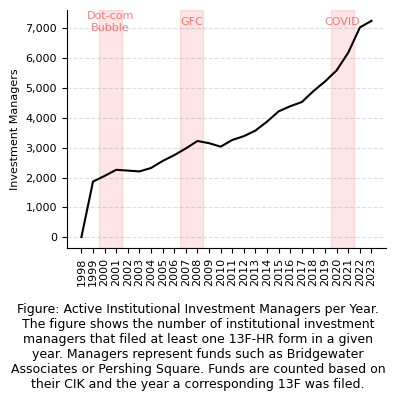

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(funds_per_year_stats["year"], funds_per_year_stats["count"], color="black")

ax.set_xticks(funds_per_year_stats["year"])
ax.set_xticklabels(funds_per_year_stats["year"], rotation=90)
ax.yaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Investment Managers")
ax.get_yaxis().set_major_formatter(
    mtick.FuncFormatter(lambda x, p: format(int(x), ","))
)

ax.axvspan(1999.5, 2001.5, alpha=0.1, color="red", zorder=-100)
ax.axvspan(2006.5, 2008.5, alpha=0.1, color="red", zorder=-100)
ax.axvspan(2019.5, 2021.5, alpha=0.1, color="red", zorder=-100)

ax.text(
    2000.5,
    ax.get_ylim()[1] - 400,
    "Dot-com\nBubble",
    horizontalalignment="center",
    verticalalignment="center",
    color="red",
    alpha=0.5,
)
ax.text(
    2007.5,
    ax.get_ylim()[1] - 400,
    "GFC",
    horizontalalignment="center",
    verticalalignment="center",
    color="red",
    alpha=0.5,
)
ax.text(
    2020.5,
    ax.get_ylim()[1] - 400,
    "COVID",
    horizontalalignment="center",
    verticalalignment="center",
    color="red",
    alpha=0.5,
)

caption = (
    "Figure: Active Institutional Investment Managers per Year. The figure shows the number of institutional investment managers that filed at least one 13F-HR form in a given year. "
    + "Managers represent funds such as Bridgewater Associates or Pershing Square. Funds are counted based on their CIK and the year a corresponding 13F was filed."
)
caption = "\n".join(textwrap.wrap(caption, 60))
fig.text(0.5, -0.30, caption, ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
total_number_of_funds = funds_filings["cik"].nunique()
print("Total number of funds (1998 - 2023):", format(total_number_of_funds, ","))

Total number of funds (1998 - 2023): 13,035


In [ ]:
funds_per_year = (
    funds_filings[["cik", "year"]]
    .copy()
    .drop_duplicates(subset=["cik", "year"])
    .sort_values(by=["year"])
    .reset_index(drop=True)
)

entering_and_exiting_funds = [
    # {
    #   "year": 2013,
    #   "entering": 210,
    #   "exiting": 10
    # },
    # {
    #   "year": 2014,
    #   "entering": 41,
    #   "exiting": 104
    # }
    # ...
]

for year in funds_per_year["year"].unique():
    funds_year = funds_per_year[funds_per_year["year"] == year]

    stats = {"year": year, "entering": 0, "exiting": 0}

    if len(entering_and_exiting_funds) == 0:
        stats["entering"] = len(funds_year["cik"])
        entering_and_exiting_funds.append(stats)
        continue

    funds_prev_year = funds_per_year[funds_per_year["year"] == year - 1]

    # calculate number of CIKs that are in funds_year, but not in funds_prev_year
    # these are new funds
    new_funds = funds_year[~funds_year["cik"].isin(funds_prev_year["cik"])]

    # calculate number of CIKs that are in funds_prev_year, but not in funds_year
    # these are funds that stopped filing
    funds_that_stopped_filing = funds_prev_year[
        ~funds_prev_year["cik"].isin(funds_year["cik"])
    ]

    stats["entering"] = len(new_funds["cik"])
    stats["exiting"] = len(funds_that_stopped_filing["cik"])

    entering_and_exiting_funds.append(stats)


entering_and_exiting_funds = pd.DataFrame(entering_and_exiting_funds)
entering_and_exiting_funds.sort_values(by=["year"], inplace=True)

print("Number of entering and exiting funds per year")
entering_and_exiting_funds[-10:]

Number of entering and exiting funds per year


,year,entering,exiting
16,2014,552,253
17,2015,564,219
18,2016,445,273
19,2017,497,357
20,2018,677,309
21,2019,618,295
22,2020,734,362
23,2021,949,354
24,2022,1175,334
25,2023,739,517


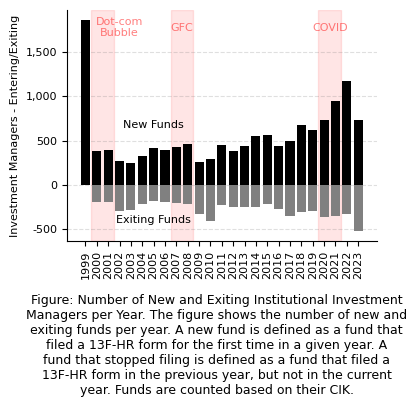

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.bar(
    entering_and_exiting_funds["year"][1:],
    entering_and_exiting_funds["entering"][1:],
    color="black",
    label="New Funds",
    zorder=100,
)

ax.bar(
    entering_and_exiting_funds["year"][1:],
    entering_and_exiting_funds["exiting"][1:] * -1,
    color="grey",
    label="Funds that Stopped Filing",
    zorder=100,
)

ax.get_yaxis().set_major_formatter(
    mtick.FuncFormatter(lambda x, p: format(int(x), ","))
)

ax.set_xticks(entering_and_exiting_funds["year"][1:])
ax.set_xticklabels(entering_and_exiting_funds["year"][1:], rotation=90)
ax.yaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# add text "New Funds" onto the figure
ax.text(
    2005,
    680,
    "New Funds",
    horizontalalignment="center",
    verticalalignment="center",
    color="black",
    fontsize=8,
)

ax.text(
    2005,
    -400,
    "Exiting Funds",
    horizontalalignment="center",
    verticalalignment="center",
    color="black",
    fontsize=8,
)

ax.axvspan(1999.5, 2001.5, alpha=0.1, color="red", zorder=-100)
ax.axvspan(2006.5, 2008.5, alpha=0.1, color="red", zorder=-100)
ax.axvspan(2019.5, 2021.5, alpha=0.1, color="red", zorder=-100)

# add text labels for financial crisis and covid
ax.text(
    2002,
    ax.get_ylim()[1] - 200,
    "Dot-com\nBubble",
    horizontalalignment="center",
    verticalalignment="center",
    color="red",
    alpha=0.5,
)
ax.text(
    2007.5,
    ax.get_ylim()[1] - 200,
    "GFC",
    horizontalalignment="center",
    verticalalignment="center",
    color="red",
    alpha=0.5,
)
ax.text(
    2020.5,
    ax.get_ylim()[1] - 200,
    "COVID",
    horizontalalignment="center",
    verticalalignment="center",
    color="red",
    alpha=0.5,
)

ax.set_ylabel("Investment Managers - Entering/Exiting")

caption = "Figure: Number of New and Exiting Institutional Investment Managers per Year. The figure shows the number of new and exiting funds per year. A new fund is defined as a fund that filed a 13F-HR form for the first time in a given year. A fund that stopped filing is defined as a fund that filed a 13F-HR form in the previous year, but not in the current year. Funds are counted based on their CIK."
caption = "\n".join(textwrap.wrap(caption, 60))
fig.text(0.5, -0.40, caption, ha="center", fontsize=9)

plt.show()

Over the past 26 years, from 1998 to 2023, our analysis reveals a dynamic landscape in the fund management industry, involving 13,035 hedge funds and investment managers. Notably, 2023 emerged as a landmark year, showcasing the highest number of active funds, with a remarkable surge in new entrants from under 500 in 2016 to over 1,000 by 2022. This period witnessed the greatest influx of newly registered funds, highlighting a significant shift in the industry's composition.

The year 2022 stood out not only for its record-setting new fund registrations but also for signaling a pronounced market adjustment. The repercussions of this strong market correction became particularly evident in 2023, a year that saw over 500 funds withdrawing from the investment arena, surpassing the exit rates observed in the aftermath of the Global Financial Crisis (GFC) in 2009 and 2010. This trend underscores a notable correlation between market downturns or recessions and an increase in the number of funds ceasing operations, with the peak of exits often coinciding with the transition from a bear to a bull market. This suggests that many funds tend to exit the market just as conditions begin to improve.

For clarity, "entering funds" are identified as those reporting a Form 13F for the first time, whereas 'exiting funds' are recognized as those with previous 13F filings but none in the given year. Given the SEC's mandate requiring quarterly disclosures (four times per year), the absence of any filings from a fund within a year is a strong indicator of its operational cessation.

## Fund Lifespan and Survival Rates

This section delves into the operational longevity of investment funds, focusing on calculating their survival rates and establishing quantiles to gauge the typical lifespan within the asset management industry.

We begin by identifying the distinct funds that submitted at least one Form 13F filing from 1998 to 2000. We then examine which of these funds remained operational in 2023, a full 23 years later, to calculate the "survival rate." This metric reflects the percentage of funds that continue to exist and operate, offering insights into the long-term viability and stability within the sector.

In [ ]:
cik_of_early_funds = funds_filings[funds_filings['year'].isin([1998,1999,2000])]['cik'].unique()
cik_of_active_funds = funds_filings[funds_filings['year'].isin([2023])]['cik'].unique()

# create intersection of cik_of_early_funds and cik_of_active_funds
cik_of_early_funds = set(cik_of_early_funds)
cik_of_active_funds = set(cik_of_active_funds)

intersection = cik_of_early_funds.intersection(cik_of_active_funds)
intersection_pct = round(len(intersection) / len(cik_of_early_funds) * 100, 2)

print("Number of funds that were active in...")
print("1998, 1999 and 2000:\t\t", len(cik_of_early_funds))
print("1998, 1999, 2000 and 2023:\t", len(intersection), f"({intersection_pct}% survival rate)")

Number of funds that were active in...
1998, 1999 and 2000:		 2256
1998, 1999, 2000 and 2023:	 659 (29.21% survival rate)


In the next step, we quantify the duration of activity for each fund by tracking the number of years it reported Form 13F filings to the SEC via EDGAR. This step involves plotting the data on a histogram where the x-axis represents the number of active years, and the y-axis shows the count of funds for each duration of activity.

Utilizing the entire period from 1998 to 2023, we create 26 distinct buckets to categorize the funds based on the number of years they were operational. This approach allows us to visualize the distribution of fund lifespans across the observed timeframe.

Following the distribution analysis, we compute basic descriptive statistics to capture the central tendency and dispersion of fund lifespans. These statistics include the mean (average number of active years), standard deviation (variation in lifespan), and the first, second (median), and third quantiles.

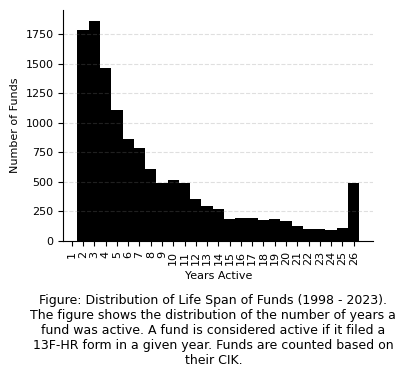

Descriptive Statistics of the Life Spans of Funds (1998 - 2023)


,years_active
count,13035.00
mean,7.22
std,6.53
min,1.00
25%,2.00
50%,5.00
75%,10.00
max,26.00


In [ ]:
ciks = funds_filings["cik"].unique()

years_active = []

for cik in ciks:
    years = funds_filings[funds_filings["cik"] == cik]["year"].unique()
    years_active.append({"cik": cik, "years_active": len(years), "years": years})

years_active = pd.DataFrame(years_active)

fig, ax = plt.subplots(figsize=(4, 3))

bins_range = range(1, 27)
ax.hist(years_active["years_active"], bins=bins_range, color="black")

# move all bars by 0.5 to the left
ax.set_xticks(np.array(bins_range) - 0.5)
ax.set_xticklabels(bins_range, rotation=90, fontsize=8, ha="center")

ax.yaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Years Active")
ax.set_ylabel("Number of Funds")

caption = (
    "Figure: Distribution of Life Span of Funds (1998 - 2023). The figure shows the distribution of "
    + "the number of years a fund was active. A fund is considered active if it filed a 13F-HR form "
    + "in a given year. Funds are counted based on their CIK."
)

caption = "\n".join(textwrap.wrap(caption, 60))
fig.text(0.5, -0.30, caption, ha="center", fontsize=9)

plt.show()

print("Descriptive Statistics of the Life Spans of Funds (1998 - 2023)")
pd.DataFrame(years_active["years_active"].describe().round(2))

The dataset, encompassing 13,035 funds, reveals a diverse landscape of fund activity durations. On average, funds have been active for approximately 7.22 years, suggesting a moderate operational lifespan across the sector. However, the standard deviation of 6.53 years highlights a significant variance in fund lifespans, indicating that while some funds operate for a brief period, others demonstrate much longer endurance.

A closer look at the distribution shows that the minimum active duration is just 1 year, reflecting the challenges some funds face in sustaining operations. The 25th percentile, at 2 years, implies that a quarter of the funds ceased filings within two years of operation. The median value of 5 years suggests that half of the funds were active for five years or less, providing a more resistant measure of central tendency against outliers compared to the average.

At the higher end, the 75th percentile reveals that three-quarters of the funds were active for 10 years or less, and 25% of all funds were active for 10 years and more, underscoring that a significant portion of the sector does not surpass a decade of activity. Remarkably, the maximum lifespan extends to 26 years, showcasing that a select few funds have managed to navigate the asset management industry successfully over the entire period analyzed.

## Evolution of Asset Values

In this part of the tutorial, we delve into the progression of asset values from 2013 to 2023 by analyzing the holdings values reported in 13F filings. This analysis aims to shed light on the performance of institutional portfolios over time, revealing how they've adapted to shifting market conditions.

**Data Extraction and Processing**

Our focus is on the aggregate holding values of all funds for the period 2013-2023. We achieve this by extracting the total value of holdings as reported on the cover page of each 13F-HR filing. The cover page provides a snapshot of a fund's reported assets, essential for evaluating fund performance at a glance.

To extract the `Form 13F Information Table Value Total` from each cover page, we first identify the URL of these pages. The URL is located in the `documentUrl` parameter within the `documentFormatFiles` array of a filing's metadata object, accessible via the Query API.

**Example of Extracting Data**

Upon locating the cover page URL, we use a basic XML parser to retrieve the `tableValueTotal`, which represents the aggregate value of the fund's holdings. Below is an example of a cover page and of how the metadata object appears, highlighting the necessary parameters for locating the cover page:


Cover page example ([source filing](https://www.sec.gov/Archives/edgar/data/2004720/000139834423022864/xslForm13F_X02/primary_doc.xml)):

![cover-page-example](https://i.imgur.com/Xy3sRNCm.png)


Filing metadata object example:
```json
{
  "formType": "13F-HR",
  "accessionNo": "0001398344-23-022864",
  "periodOfReport": "2023-09-30",
  "documentFormatFiles": [
    {
      "sequence": "1",
      "documentUrl": "https://www.sec.gov/Archives/edgar/data/2004720/000139834423022864/xslForm13F_X02/primary_doc.xml",
      "type": "13F-HR"
    }
  ]
}
```

**Data Collection and Standardization**

For efficiency, we've already gathered this information using the Query API and further processed it using the Render API to obtain and parse all relevant cover pages. This process involved extracting the number of holdings and their total value from each 13F filing's cover page. Given the challenge of over 30% of holding values being incorrectly reported across all funds, we applied various outlier detection algorithms to standardize the data.

The final dataset, encapsulated in `cover-pages-cleaned.csv`, includes seven columns: the CIK of the fund, filing date and time, the `periodOfReport` (referring to the filing's quarter), accession number, number of holdings, reported value of all holdings, and the standardized holdings value — a figure refined through our outlier detection and standardization process.

In [ ]:
cover_pages = pd.read_csv("./data/cover-pages-cleaned.csv", parse_dates=["periodOfReport", "filedAt"])
print("13F Cover Pages (2013 - 2023)")
cover_pages.sort_values(by=["filedAt"])

13F Cover Pages (2013 - 2023)


,filerCik,filedAt,periodOfReport,accessionNo,numberHoldings,holdingsValueReported,holdingsValueStandardized
1898,1040592,2013-10-01 09:47:12-04:00,2013-09-30,0001040592-13-000013,59,4121959,4121959000
2988,767684,2013-10-01 11:38:08-04:00,2013-09-30,0000767684-13-000012,122,881429,881429000
790,1452208,2013-10-01 12:08:50-04:00,2013-09-30,0001144204-13-053268,81,581943,581943000
1691,805676,2013-10-01 12:12:11-04:00,2013-09-30,0001144204-13-053271,541,1307390845,1307390845
1869,1426588,2013-10-01 16:57:06-04:00,2013-09-30,0001426588-13-000006,182,194373,194373000
...,...,...,...,...,...,...,...
88386,2004720,2023-12-21 18:22:18-05:00,2018-12-31,0001398344-23-023296,482,129656986,129656986
95270,2004720,2023-12-21 18:24:48-05:00,2019-06-30,0001398344-23-023298,469,160161167,160161167
90360,2004720,2023-12-21 18:26:06-05:00,2019-03-31,0001398344-23-023299,472,142784489,142784489
99088,2004720,2023-12-21 18:28:56-05:00,2019-09-30,0001398344-23-023302,487,167369301,167369301


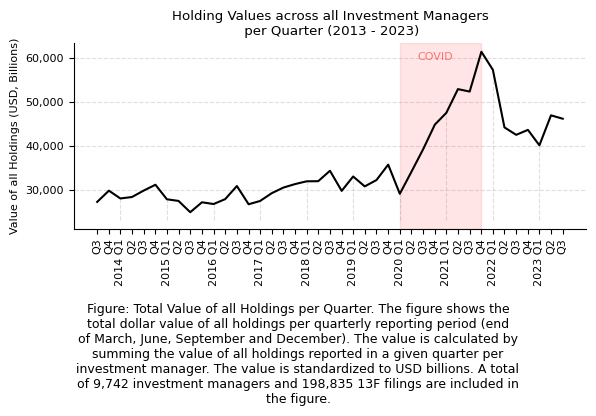

In [ ]:
def plot_holding_values(cover_pages):
    fig, ax = plt.subplots(figsize=(6, 3))

    cover_pages_grouped = cover_pages.groupby("periodOfReport")
    cover_pages_grouped = (
        cover_pages_grouped["holdingsValueStandardized"].sum().to_frame().reset_index()
    )

    ax.plot(
        cover_pages_grouped["periodOfReport"],
        cover_pages_grouped["holdingsValueStandardized"],
        color="black",
    )

    xticks = cover_pages_grouped["periodOfReport"].dt.date.unique().tolist()
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, rotation=90)
    ax.yaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # draw vertical lines for every Q1. e.g. 2013-03-31, 2014-03-31, 2015-03-31, ...
    y_min = ax.get_ylim()[0]

    for year in cover_pages_grouped["periodOfReport"].dt.year.unique():
        x_value = str(year) + "-03-31"
        x_value = pd.to_datetime(x_value, format="%Y-%m-%d")
        if (x_value in cover_pages_grouped["periodOfReport"].values) == False:
            continue
        y_value = cover_pages_grouped[cover_pages_grouped["periodOfReport"] == x_value][
            "holdingsValueStandardized"
        ].values[0]

        ax.vlines(
            x=x_value,
            ymin=y_min,
            ymax=y_value,
            color="grey",
            alpha=0.25,
            zorder=-100,
            linestyle="--",
            linewidth=0.8,
        )

    ax.set_ylabel("Value of all Holdings (USD, Billions)")

    ax.get_yaxis().set_major_formatter(
        mtick.FuncFormatter(lambda x, p: format(int(x) / 1000000000, ",.0f"))
    )

    ax.axvspan(
        pd.to_datetime("2020-03-31", format="%Y-%m-%d"),
        pd.to_datetime("2021-12-31", format="%Y-%m-%d"),
        alpha=0.1,
        color="red",
        zorder=-100,
    )

    ax.text(
        pd.to_datetime("2020-12-31", format="%Y-%m-%d"),
        ax.get_ylim()[1] * 0.95,
        "COVID",
        horizontalalignment="center",
        verticalalignment="center",
        color="red",
        alpha=0.5,
    )

    ax.set_title(
        "Holding Values across all Investment Managers\n per Quarter (2013 - 2023)"
    )

    total_number_of_funds = cover_pages["filerCik"].nunique()
    number_of_13F_filings = cover_pages["accessionNo"].nunique()

    caption = (
        "Figure: Total Value of all Holdings per Quarter. The figure shows the total dollar value of all holdings per quarterly reporting period (end of March, June, September and December). "
        + "The value is calculated by summing the value of all holdings reported in a given quarter per investment manager. The value is standardized to USD billions. "
        + f"A total of {format(total_number_of_funds, ',')} investment managers and {format(number_of_13F_filings, ',')} 13F filings are included in the figure. "
    )

    caption = "\n".join(textwrap.wrap(caption, 70))
    fig.text(0.5, -0.35, caption, ha="center", fontsize=9)

    # replace x labels with year and quarter
    def get_quarter(period):
        if period.month == 3:
            return "Q1"
        elif period.month == 6:
            return "Q2"
        elif period.month == 9:
            return "Q3"
        elif period.month == 12:
            return "Q4"
        else:
            return "Q0"

    def format_period(period):
        qtr = get_quarter(period)
        if qtr != "Q1":
            return qtr
        return str(period)[0:4] + " " + get_quarter(period)

    ax.set_xticklabels(
        [format_period(period) for period in xticks],
        rotation=90,
        ha="center",
        fontsize=8,
    )

    plt.tight_layout()
    plt.show()


plot_holding_values(cover_pages)

The figure presents a time series analysis of the aggregated dollar value of holdings reported quarterly by investment managers, delineating the standard reporting periods that conclude at the end of March, June, September, and December.

The trend from the beginning of 2013 to the onset of 2020 is characterized by a relative stagnation in holding values, suggesting a period of flat growth across the combined portfolios of the investment industry. During this timeframe, the growth in total holdings value does not exhibit significant upward momentum.

A pivotal shift in the trajectory of holding values is marked by the COVID-19 pandemic. From 2020 to the end of 2021, there is an escalation in holding values, reflecting perhaps a reactive surge in investment during the pandemic period. In the fourth quarter of 2021, the aggregated assets reached an unprecedented peak, surpassing $60 trillion. This surge is subsequently countered by a downturn that coincides with the market correction in 2022, indicating a retraction of holding values in response to changing economic conditions.

## Ranking Funds by Performance Factors

Our analysis extends to calculating factors to rank and compare funds by performance. We focus on measures such as maximum drawdown, Sharpe and Sortine ratio, beta, alpha, and annualized returns to establish a ranking of the top-performing funds.

### Outlier Detection

A crucial step before computing these metrics is the exclusion of erroneous data through an outlier detection method as roughly 12% of funds active in 2023 have discrepancies in their 13F filings. These errors stretch beyond the variations we cleaned in the first chapter of this tutorial, and are not merely superficial but rather substantial. They range from the incorrectly swapping the number of holdings with the aggregate holding values, to inaccuracies in the reporting of aggregate holding values, such as missing million-dollar units. Additionally, some funds have submitted duplicate filings for a single period or have reported an implausible zero total holding value.

To address these issues, the outlier detection algorithm in the `detect_outliers` function pinpoints outliers by their percentage changes. The process begins by calculating the percentage change between consecutive `holdingsValueStandardized` entries in the cover pages of a specific fund. We then apply a threshold of 2000% to flag significant increases as outliers. If a row doesn't initially qualify as an outlier but is preceded by one that does — and the percentage change is neither excessively high nor too low — it too is classified as outlier. This approach ensures we capture outliers that could be part of an anomaly spanning multiple periods. Further refinement is done for drastic drops, with a -96% threshold used to identify extreme decreases in holding values. The resulting cover pages dataframe for a given fund includes a new column `outlier` with boolean flags for these deviations.

In [ ]:
def detect_outliers(df, column):
    outliers_df = df.copy()
    outliers_df["pctChange"] = outliers_df[column].pct_change()
    outlier_threshold_1 = 20
    outliers_df["outlier"] = outliers_df["pctChange"] > outlier_threshold_1
    outliers_df["outlierPrevRow"] = (
        outliers_df["outlier"].shift(1).fillna(False).astype(bool)
    )
    outliers_df["outlier"] = (outliers_df["outlier"] == False) & outliers_df[
        "outlierPrevRow"
    ] & (outliers_df["pctChange"] < 0.7) & (
        outliers_df["pctChange"] > -0.5
    ) | outliers_df[
        "outlier"
    ]
    outliers_df["outlierPrevRow"] = (
        outliers_df["outlier"].shift(1).fillna(False).astype(bool)
    )
    outliers_df["outlier"] = (outliers_df["pctChange"] < -0.96) & ~outliers_df[
        "outlier"
    ] & ~outliers_df["outlierPrevRow"] | outliers_df["outlier"]
    outliers_df["outlierPrevRow"] = (
        outliers_df["outlier"].shift(1).fillna(False).astype(bool)
    )
    return outliers_df


print("Example of a fund (CIK: 1906802) with outliers:")
outliers_example = detect_outliers(
    cover_pages[cover_pages["filerCik"] == 1906802], "holdingsValueStandardized"
)
outliers_example[
    [
        "periodOfReport",
        "numberHoldings",
        "holdingsValueReported",
        "holdingsValueStandardized",
        "outlier",
    ]
]

Example of a fund (CIK: 1906802) with outliers:


,periodOfReport,numberHoldings,holdingsValueReported,holdingsValueStandardized,outlier
157623,2022-03-31,143,132484,132484000,False
164326,2022-06-30,128225,137,137000,True
174902,2022-12-31,145,132717600,132717600,True
180237,2023-03-31,143,133881144,133881144,True
187673,2023-06-30,143,141582997,141582997,False
192217,2023-09-30,143,131914090,131914090,False


In [ ]:
active_ciks_in_2023 = cover_pages[cover_pages["periodOfReport"].dt.year == 2023]['filerCik'].unique().tolist()

active_ciks_wo_outliers = []
active_ciks_with_outliers = []

for cik in active_ciks_in_2023:
    cik_df = cover_pages[cover_pages['filerCik'] == cik]
    outliers = detect_outliers(cik_df, 'holdingsValueStandardized')
    has_outliers = outliers['outlier'].any()
    if has_outliers == False:
        active_ciks_wo_outliers.append(cik)
    else:
        active_ciks_with_outliers.append(cik)

pct_of_funds_w_outliers = round(len(active_ciks_with_outliers) / len(active_ciks_in_2023) * 100, 2)
print("Active funds in 2023:", format(len(active_ciks_in_2023), ","))
print("Active funds with outliers:", format(len(active_ciks_with_outliers), ","), f"({pct_of_funds_w_outliers}%)")
print("Active funds without outliers:", format(len(active_ciks_wo_outliers), ","))

Active funds in 2023: 6,966
Active funds with outliers: 814 (11.69%)
Active funds without outliers: 6,152


### Performance Metrics Calculation & Ranking

To ascertain the relative performance of investment funds, we apply a range of metrics to rank and sort them effectively:

- **Total Return:** This measures the change from the first quarter's total holdings value to the most recent quarter, providing a snapshot of overall growth or decline.
- **Asset Growth Rates:** We evaluate performance over one, three, and five years based on asset growth rates. This metric focuses on the appreciation of the assets themselves, independent of new capital inflows.
- **Maximum Drawdown:** By examining quarter-over-quarter peak-to-trough declines in the aggregated value of all holdings, we assess the largest potential loss experienced over a specified period.
- **Annualized Volatility:** We calculate this as the standard deviation of quarterly returns, offering insight into the variability of fund returns over time.
- **Sharpe Ratio:** This common measure of risk-adjusted return divides the fund's annualized return by its annualized volatility.
- **Sortino Ratio:** Similar to the Sharpe Ratio, the Sortino Ratio measures the risk-adjusted return but uses only the annualized downside volatility, focusing on negative asset price volatility.
- **Beta:** Beta provides a measure of a fund's volatility relative to the overall market.
- **Alpha:** Alpha indicates the fund's ability to outperform the market benchmark on a risk-adjusted basis.
- **T-Statistics and P-Values:** These statistical measures test the significance of fund returns against benchmark returns, crucial for establishing the reliability of performance differences.
- **Most Recent Total Holdings Value:** This figure reflects the latest reported aggregate value of a fund's holdings.
- **Number of Reporting Periods:** The total number of quarters for which the fund has reported data.
- **Number of Recently Reported Holdings:** This is the count of holdings reported in the most recent filing period.

For the purpose of these calculations, we adopt a 2% annualized risk-free rate. The S&P 500 index, accessed via the ETF ticker SPY, serves as our benchmark. Historical adjusted closing prices are sourced from Yahoo Finance, enabling us to compute both beta and alpha for each fund with respect to this benchmark.

In [ ]:
from scipy import stats


def get_time_factor(return_period=None):
    if not return_period in ["daily", "monthly", "quarterly", "Q", "yearly"]:
        raise ValueError(
            'return_period must be one of: ["daily", "weekly", "monthly", "quarterly", "yearly"]'
        )

    if return_period == "daily":
        return 252
    elif return_period == "monthly":
        return 12
    elif return_period == "quarterly" or return_period == "Q":
        return 4
    elif return_period == "yearly":
        return 1


@round_decorator(3)
def calculate_annualized_returns(fund_cover_pages):
    quarter = fund_cover_pages["periodOfReport"].dt.quarter.values[-1]
    period_mask = fund_cover_pages["periodOfReport"].dt.quarter == quarter
    holding_values = fund_cover_pages[period_mask]
    annual_returns = (1 + holding_values["holdingsValueStandardized"].pct_change()) ** (
        1 / 1
    ) - 1
    periods = holding_values["periodOfReport"]

    return pd.DataFrame({"annual_returns": annual_returns, "periods": periods}).dropna()


@round_decorator(3)
def calculate_beta(portfolio_returns, benchmark_returns):
    if len(portfolio_returns) == 0:
        return np.nan
    covariance = np.cov(portfolio_returns, benchmark_returns)[0][1]
    benchmark_variance = np.var(benchmark_returns)
    beta = covariance / benchmark_variance
    return beta


@round_decorator(3)
def calculate_alpha(
    portfolio_returns, benchmark_returns, risk_free_rate, beta, return_period
):
    if len(portfolio_returns) == 0:
        return np.nan
    time_factor = get_time_factor(return_period)
    portfolio_annual_return = np.mean(portfolio_returns) * time_factor
    benchmark_annual_return = np.mean(benchmark_returns) * time_factor
    alpha = portfolio_annual_return - (
        risk_free_rate + beta * (benchmark_annual_return - risk_free_rate)
    )
    return alpha


@round_decorator(3)
def calculate_sharpe_ratio(portfolio_returns, risk_free_rate, return_period):
    if len(portfolio_returns) == 0:
        return np.nan
    time_factor = get_time_factor(return_period)

    annualized_return = np.mean(portfolio_returns) * time_factor
    annualized_std = np.std(portfolio_returns) * np.sqrt(time_factor)

    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_std

    return sharpe_ratio


@round_decorator(3)
def calculate_sortino_ratio(
    portfolio_returns, minimum_acceptable_return, return_period
):
    if len(portfolio_returns) == 0:
        return np.nan

    time_factor = get_time_factor(return_period)

    # convert annualized MAR to a daily/weekly/quarterly rate
    normalized_mar = (1 + minimum_acceptable_return) ** (1 / time_factor) - 1
    # difference between portfolio returns and the MAR
    excess_returns = portfolio_returns - normalized_mar
    negative_excess_returns = excess_returns[excess_returns < 0]

    if len(negative_excess_returns) == 0:
        return np.nan

    average_return = np.mean(portfolio_returns)
    downside_deviation = np.std(negative_excess_returns)

    annualized_return = average_return * time_factor
    annualized_downside_deviation = downside_deviation * np.sqrt(time_factor)

    if annualized_downside_deviation == 0:
        return np.nan

    sortino_ratio = (annualized_return - normalized_mar) / annualized_downside_deviation

    return sortino_ratio


def calculate_t_stat(portfolio_returns, benchmark_returns):
    t_statistic, p_value = stats.ttest_ind(portfolio_returns, benchmark_returns)
    return t_statistic, p_value

In [ ]:
import yfinance as yf


def get_spy_data():
    start_date = cover_pages["periodOfReport"].min() - pd.Timedelta(days=3)
    end_date = cover_pages["periodOfReport"].max() + pd.Timedelta(days=3)

    print("Start date:", start_date)
    print("End date:", end_date)

    spy_data = yf.download(
        "SPY",
        start=start_date,
        end=end_date,
    )

    # check for each portfolio_values["date"].dt.date.unique() if it exists in spy_data.index
    # if not, check if next day exists in spy_data.index. if not, check if next next day exists in spy_data.index
    # add all dates that exist to dates_filter
    dates_filter = []

    for date in pd.to_datetime(cover_pages["periodOfReport"].dt.date.unique().tolist()):
        if date in spy_data.index:
            dates_filter.append(date)
        else:
            new_date = date - pd.Timedelta(days=1)
            if new_date in spy_data.index:
                dates_filter.append(new_date)
            else:
                new_date = date - pd.Timedelta(days=2)
                if new_date in spy_data.index:
                    dates_filter.append(new_date)
                else:
                    print(f"no date for {date}")

    spy_data = spy_data[spy_data.index.isin(dates_filter)].copy()

    spy_data.drop(columns=["Open", "High", "Low", "Close", "Volume"], inplace=True)

    # standardize dates to that they all represent the end of the quarter
    # e.g. "2013-06-28" -> "2013-06-30"
    def to_quarter_end(date):
        if date.month == 3:
            return date.replace(day=31)
        elif date.month == 6:
            return date.replace(day=30)
        elif date.month == 9:
            return date.replace(day=30)
        elif date.month == 12:
            return date.replace(day=31)
        else:
            return date

    new_index = pd.Series(spy_data.index).apply(to_quarter_end)

    spy_data.set_index(new_index, inplace=True)

    return spy_data


@memoize
def get_benchmark_returns(periods):
    adj_close = spy_data[spy_data.index.isin(periods)]
    returns = adj_close["Adj Close"].pct_change().dropna()
    return returns


spy_data = get_spy_data()
print(f"Rows: {len(spy_data)}")
spy_data.head()

Start date: 2013-09-27 00:00:00
End date: 2023-10-03 00:00:00
[*********************100%%**********************]  1 of 1 completed
Rows: 41


,Adj Close
Date,
2013-09-30,139.467758
2013-12-31,154.146393
2014-03-31,156.771637
2014-06-30,164.859512
2014-09-30,166.730240


In [ ]:
risk_free_rate = 0.02  # annualized


def get_fund_performance_metrics(fund_cover_pages):
    fund_cover_pages = fund_cover_pages.drop_duplicates(subset=["periodOfReport"])
    fund_cover_pages = fund_cover_pages[
        fund_cover_pages["holdingsValueStandardized"] > 0
    ]
    metrics = {}

    if len(fund_cover_pages) < 1:
        return None

    last_row = fund_cover_pages.iloc[-1]
    quarter = last_row["periodOfReport"].quarter
    recent_year = last_row["periodOfReport"].year

    metrics["assetValue"] = last_row["holdingsValueStandardized"].sum()
    metrics["#holdings"] = last_row["numberHoldings"]
    metrics["firstPeriod"] = fund_cover_pages.iloc[0]["periodOfReport"]
    periods = fund_cover_pages["periodOfReport"].dt.date.unique().tolist()
    metrics["#periods"] = len(periods)

    if len(fund_cover_pages) <= 4:
        return metrics

    metrics["maxDrawdownQtrPct"] = round(
        fund_cover_pages["holdingsValueStandardized"].pct_change().min() * 100, 2
    )

    row_5yr = fund_cover_pages[
        (fund_cover_pages["periodOfReport"].dt.year == recent_year - 5)
        & (fund_cover_pages["periodOfReport"].dt.quarter == quarter)
    ]
    row_3yr = fund_cover_pages[
        (fund_cover_pages["periodOfReport"].dt.year == recent_year - 3)
        & (fund_cover_pages["periodOfReport"].dt.quarter == quarter)
    ]
    row_1yr = fund_cover_pages[
        (fund_cover_pages["periodOfReport"].dt.year == recent_year - 1)
        & (fund_cover_pages["periodOfReport"].dt.quarter == quarter)
    ]

    quarterly_returns = (
        fund_cover_pages["holdingsValueStandardized"].pct_change().dropna()
    )
    periods = fund_cover_pages["periodOfReport"].dt.date.unique().tolist()
    benchmark_returns = get_benchmark_returns(periods)

    if len(row_1yr) > 0:
        if row_1yr["holdingsValueStandardized"].values[0] > 0:
            pct_change_1yr = (
                last_row["holdingsValueStandardized"]
                - row_1yr["holdingsValueStandardized"].values[0]
            ) / row_1yr["holdingsValueStandardized"].values[0]
        else:
            pct_change_1yr = 0

        annualized_volatility = fund_cover_pages[
            "holdingsValueStandardized"
        ].pct_change().std() * np.sqrt(4)

        beta = calculate_beta(quarterly_returns, benchmark_returns)

        alpha = calculate_alpha(
            quarterly_returns, benchmark_returns, risk_free_rate, beta, "Q"
        )

        sharpe_ratio = calculate_sharpe_ratio(quarterly_returns, risk_free_rate, "Q")
        sortino_ratio = calculate_sortino_ratio(quarterly_returns, risk_free_rate, "Q")
        t_stat_benchmark, p_value_benchmark = calculate_t_stat(
            quarterly_returns, benchmark_returns
        )

        metrics["volYr"] = round(annualized_volatility, 2)
        metrics["sharpe"] = sharpe_ratio
        metrics["sortino"] = sortino_ratio
        metrics["beta"] = beta
        metrics["alpha"] = alpha
        metrics["t-stat"] = round(t_stat_benchmark, 3)
        metrics["p"] = round(p_value_benchmark, 3)
        metrics["assets.pct_change_1yr"] = round(pct_change_1yr * 100, 2)

    if len(row_3yr) > 0 and row_3yr["holdingsValueStandardized"].values[0] > 0:
        pct_change_3yr = (
            last_row["holdingsValueStandardized"]
            - row_3yr["holdingsValueStandardized"].values[0]
        ) / row_3yr["holdingsValueStandardized"].values[0]
        metrics["assets.pct_change_3yr"] = round(pct_change_3yr * 100, 2)
    else:
        metrics["assets.pct_change_3yr"] = np.nan

    if len(row_5yr) > 0 and row_5yr["holdingsValueStandardized"].values[0] > 0:
        pct_change_5yr = (
            last_row["holdingsValueStandardized"]
            - row_5yr["holdingsValueStandardized"].values[0]
        ) / row_5yr["holdingsValueStandardized"].values[0]
        metrics["assets.pct_change_5yr"] = round(pct_change_5yr * 100, 2)
    else:
        metrics["assets.pct_change_5yr"] = np.nan

    return metrics


print("Single fund performance metrics (CIK: 1759236)")
get_fund_performance_metrics(cover_pages[cover_pages["filerCik"] == 1759236])

Single fund performance metrics (CIK: 1759236)


{'assetValue': 324876323,
 '#holdings': 111,
 'firstPeriod': Timestamp('2019-03-31 00:00:00'),
 '#periods': 19,
 'maxDrawdownQtrPct': -19.87,
 'volYr': 0.29,
 'sharpe': 0.932,
 'sortino': 1.784,
 'beta': 1.046,
 'alpha': 0.147,
 't-stat': 0.924,
 'p': 0.362,
 'assets.pct_change_1yr': 30.9,
 'assets.pct_change_3yr': 82.12,
 'assets.pct_change_5yr': nan}

In [ ]:
risk_free_rate = 0.02  # annualized


def get_performance_metrics(cover_pages):
    performance_by_cik = {}

    for cik in cover_pages["filerCik"].unique():
        try:
            metrics = get_fund_performance_metrics(
                cover_pages[cover_pages["filerCik"] == cik]
            )
            if metrics is not None:
                performance_by_cik[cik] = metrics
        except Exception as e:
            print(f"Error for cik {cik}: {e}")

    performance_by_cik = pd.DataFrame.from_dict(
        performance_by_cik, orient="index"
    ).reset_index(names=["cik"])
    return performance_by_cik

In [ ]:
all_funds_metrics = get_performance_metrics(cover_pages)

In [ ]:
active_funds_metrics = all_funds_metrics[all_funds_metrics["cik"].isin(active_ciks_wo_outliers)]

In [ ]:
long_active_funds_mask = active_funds_metrics["firstPeriod"].dt.year <= 2018
positive_sharpe_mask = active_funds_metrics["sharpe"] > 0
positive_5yr_change_mask = active_funds_metrics["assets.pct_change_5yr"] > 0

best_performing = active_funds_metrics[
    long_active_funds_mask & positive_sharpe_mask & positive_5yr_change_mask
].copy()

best_performing.sort_values(by=["sharpe"], ascending=False, inplace=True)
best_performing.reset_index(drop=True, inplace=True)

print(f"Ranking of {len(best_performing):,} filtered funds active in 2023 ranked by their Sharpe ratio:")
best_performing.head(10)

Ranking of 2,047 filtered funds active in 2023 ranked by their Sharpe ratio:


,cik,assetValue,#holdings,firstPeriod,#periods,maxDrawdownQtrPct,volYr,sharpe,sortino,beta,alpha,t-stat,p,assets.pct_change_1yr,assets.pct_change_3yr,assets.pct_change_5yr
0,1737109,5668882543,1557,2018-03-31,22,-8.66,0.31,2.181,12.280,1.163,0.530,3.403,0.002,81.11,249.45,1612.68
1,1698218,2227118451,702,2017-06-30,26,-8.98,0.18,2.048,5.372,0.580,0.307,2.497,0.016,18.26,150.13,463.99
2,838618,772954565,338,2018-03-31,23,-2.77,0.20,1.956,24.062,0.860,0.298,2.333,0.025,40.71,214.78,561.58
3,354497,6123311000,512,2018-03-31,22,-10.91,0.22,1.877,6.070,0.563,0.330,2.159,0.037,22.87,125.88,418.69
4,1731061,1016916977,1706,2018-03-31,23,-7.98,0.27,1.839,6.757,0.623,0.422,2.663,0.011,44.65,317.55,1062.82
5,1540235,74941949688,4350,2013-09-30,41,-15.36,0.15,1.836,2.657,0.858,0.180,2.435,0.017,29.61,95.65,178.02
6,1744073,2070307627,297,2017-03-31,25,-13.82,0.21,1.829,5.238,0.911,0.272,2.200,0.033,9.05,129.71,326.88
7,1482880,6702866033,798,2013-09-30,41,-14.24,0.22,1.773,4.059,0.566,0.317,3.247,0.002,108.81,358.45,1103.50
8,1141802,76903880909,3266,2013-09-30,41,-17.98,0.23,1.722,3.406,0.680,0.319,3.269,0.002,34.15,106.95,288.03
9,1721608,1646575000,82,2017-12-31,24,-11.27,0.25,1.704,4.870,0.572,0.365,2.425,0.019,38.92,97.45,425.19


### Visualizing Fund Performance Relative to the Benchmark

Building on the Sharpe ratio rankings from the previous analysis, we proceed to visualize the performance trajectories of the leading funds. The goal is to compare these funds' growth over time with the S&P 500 benchmark, offering a perspective on the merits of active management against a passive market strategy. This visualization may also provide insights into the advantages of cloning the investment strategies of high-performing funds.

We will focus on the top 15 funds with the strongest performance records. To ensure a fair comparison, the S&P 500 index's performance is normalized to match the initial value reported by each fund in the first quarter of their respective reporting period. This approach allows for a direct, relative performance assessment over the same timeframe.

CIK: 1737109


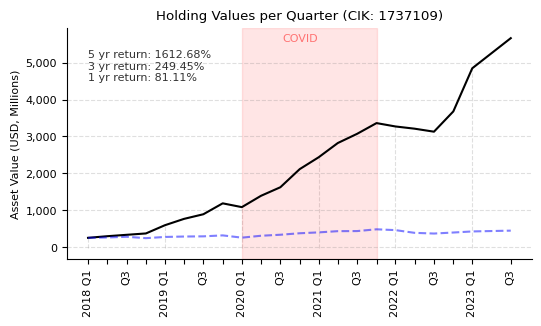

In [ ]:
def get_quarter(period):
    if period.month == 3:
        return "Q1"
    elif period.month == 6:
        return "Q2"
    elif period.month == 9:
        return "Q3"
    elif period.month == 12:
        return "Q4"
    else:
        return period


def format_period(period):
    qtr = get_quarter(period)
    if qtr == "Q3":
        return qtr
    if qtr != "Q1":
        # return qtr
        return ""
    return str(period)[0:4] + " " + get_quarter(period)


def plot_assets_over_time(cover_pages_of_cik, ax=None, show_y_axis_label=True, title=None):
    cik = cover_pages_of_cik.iloc[0]["filerCik"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3))

    ax.plot(
        cover_pages_of_cik["periodOfReport"],
        cover_pages_of_cik["holdingsValueStandardized"],
        color="black",
    )

    periods = cover_pages_of_cik["periodOfReport"].dt.date.unique().tolist()
    benchmark = spy_data[spy_data.index.isin(periods)].copy()

    # scale benchmark to same scale as holdingsValueStandardized
    benchmark["value_positions"] = (
        benchmark["Adj Close"] / benchmark["Adj Close"].iloc[0]
    ) * cover_pages_of_cik["holdingsValueStandardized"].values[0]

    ax.plot(
        benchmark.index,
        benchmark["value_positions"],
        color="blue",
        linestyle="--",
        alpha=0.5,
    )

    xticks = cover_pages_of_cik["periodOfReport"].dt.date.unique().tolist()

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, rotation=90, fontsize=6)

    ax.yaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if show_y_axis_label:
        ax.set_ylabel("Asset Value (USD, Millions)")
    ax.get_yaxis().set_major_formatter(
        mtick.FuncFormatter(lambda x, p: format(int(x) / 1000000, ",.0f"))
    )
    # ax.set_title(f"CIK {cik} - Holdings Value over Time")
    ax.set_title(f"CIK {cik}" if title is None else title)

    y_min = ax.get_ylim()[0]

    for year in cover_pages_of_cik["periodOfReport"].dt.year.unique():
        x_value = str(year) + "-03-31"
        x_value = pd.to_datetime(x_value, format="%Y-%m-%d")
        if (x_value in cover_pages_of_cik["periodOfReport"].values) == False:
            continue
        y_value = cover_pages_of_cik[cover_pages_of_cik["periodOfReport"] == x_value][
            "holdingsValueStandardized"
        ].values[0]
        ax.vlines(
            x=x_value,
            ymin=y_min,
            ymax=y_value,
            color="grey",
            alpha=0.25,
            zorder=-100,
            linestyle="--",
            linewidth=0.8,
        )

    ax.axvspan(
        pd.to_datetime("2020-03-31", format="%Y-%m-%d"),
        pd.to_datetime("2021-12-31", format="%Y-%m-%d"),
        alpha=0.1,
        color="red",
        zorder=-100,
    )

    ax.text(
        pd.to_datetime("2020-12-31", format="%Y-%m-%d"),
        ax.get_ylim()[1] * 0.95,
        "COVID",
        horizontalalignment="center",
        verticalalignment="center",
        color="red",
        alpha=0.5,
    )

    pct_growth_5yr = 0
    pct_growth_3yr = 0
    pct_growth_1yr = 0

    fund_metrics = all_funds_metrics[all_funds_metrics["cik"] == cik]

    try:
        pct_growth_5yr = "{:.2f}%".format(fund_metrics.iloc[0]["assets.pct_change_5yr"])
    except:
        pass
    try:
        pct_growth_3yr = "{:.2f}%".format(fund_metrics.iloc[0]["assets.pct_change_3yr"])
    except:
        pass
    try:
        pct_growth_1yr = "{:.2f}%".format(fund_metrics.iloc[0]["assets.pct_change_1yr"])
    except:
        pass

    # add text to figure
    # get x-anchor by getting first x value of xticks
    x_anchor = xticks[0]
    ax.text(
        x_anchor,
        ax.get_ylim()[1] * 0.90,
        f"5 yr return: {pct_growth_5yr}\n3 yr return: {pct_growth_3yr}\n1 yr return: {pct_growth_1yr}",
        horizontalalignment="left",
        verticalalignment="top",
        color="black",
        alpha=0.8,
    )

    number_of_13F_filings = cover_pages_of_cik["accessionNo"].nunique()

    caption = (
        f"Figure: Quarterly Value of all Holdings of Fund {cik}. The figure shows the total dollar value of all holdings per quarterly reporting period (end of March, June, September and December). "
        + f"A total of {format(number_of_13F_filings, ',')} 13F filings are included in the figure. "
    )

    caption = "\n".join(textwrap.wrap(caption, 70))

    # replace x labels with year and quarter
    ax.set_xticklabels(
        [format_period(period) for period in xticks],
        rotation=90,
        ha="center",
        fontsize=8,
    )


cik = best_performing.iloc[0]["cik"]
print("CIK:", cik)
plot_assets_over_time(cover_pages[cover_pages["filerCik"] == cik], title=f"Holding Values per Quarter (CIK: {cik})")

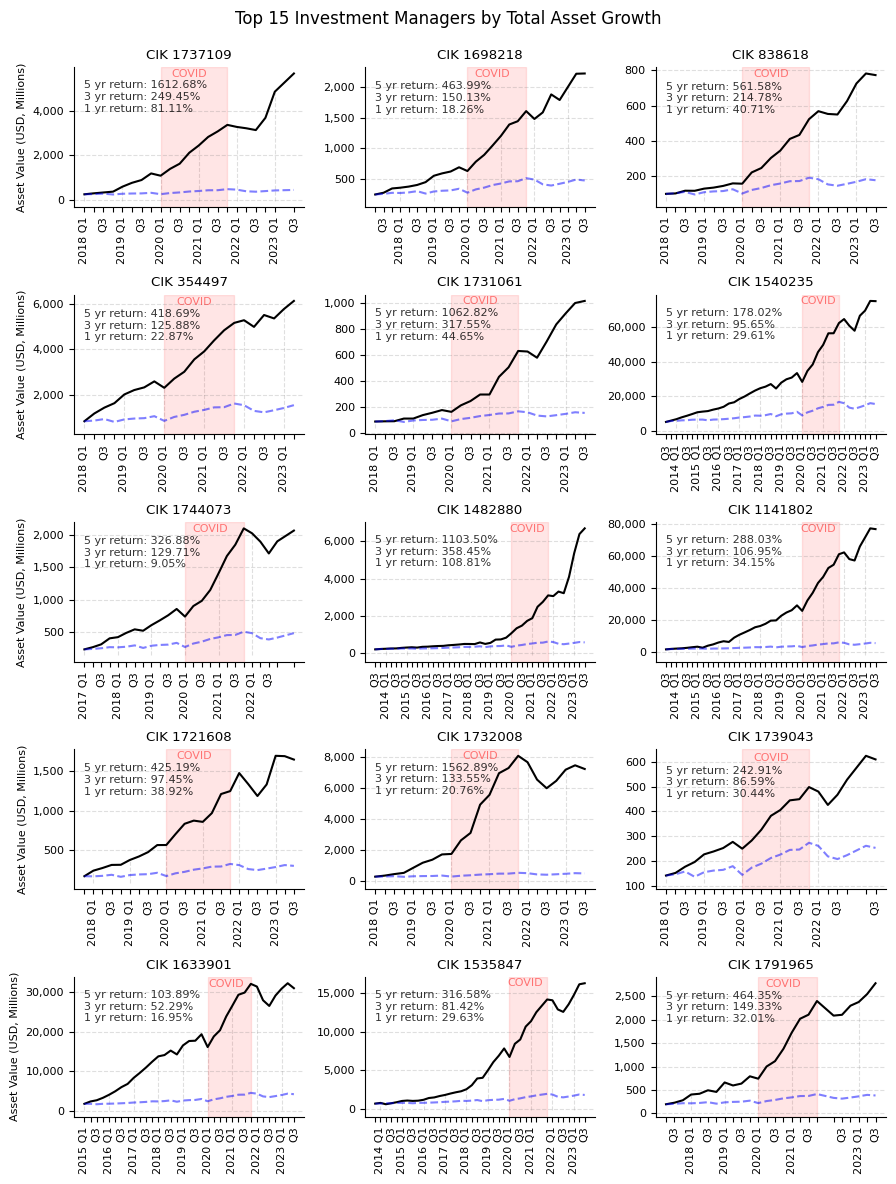

In [ ]:
fig, axs = plt.subplots(5, 3, figsize=(9, 12))

for i in range(0, 15):
    cik = best_performing.iloc[i]['cik']
    row = i // 3
    col = i % 3
    show_y_axis_label = i % 3 == 0
    plot_assets_over_time(cover_pages[cover_pages["filerCik"] == cik], ax=axs[row, col], show_y_axis_label=show_y_axis_label)

fig.suptitle("Top 15 Investment Managers by Total Asset Growth\n", fontsize=12)
plt.tight_layout()
plt.show()

### Alpha Distribution Across Funds

In our final analysis, we turn our attention to the distribution of alpha among all funds over the past decade. Alpha, a key indicator of excess return on a risk-adjusted basis, serves as a measure of a fund's ability to beat the market. We will categorize funds into different alpha groups and assess the performance distribution within these segments. The objective is to determine the prevalence and degree of market outperformance among funds. This examination seeks to identify the frequency and quantity of funds that consistently achieve returns above market benchmarks.

In [ ]:
cik_filter = [1525947, 1801507, 1476534, 96223, 1532618, 1761013, 1781948, 1720777, 1820680, 714142]

data_to_plot = all_funds_metrics[
    (all_funds_metrics['alpha'].isna() == False)
    & (all_funds_metrics["alpha"] < 3)
    & (all_funds_metrics["alpha"] > -3)
    & (all_funds_metrics["#periods"] > 5)
    & (all_funds_metrics["#holdings"] > 5)
    & (all_funds_metrics["assets.pct_change_3yr"].isna() == False)
    & (all_funds_metrics["maxDrawdownQtrPct"] > -70)
]

data_to_plot.sort_values(by='alpha', ascending=False).head(10)

,cik,assetValue,#holdings,firstPeriod,#periods,maxDrawdownQtrPct,volYr,sharpe,sortino,beta,alpha,t-stat,p,assets.pct_change_1yr,assets.pct_change_3yr,assets.pct_change_5yr
6075,1761013,25903856830,1821,2019-03-31,19,-67.95,7.16,0.491,7.630,6.704,2.685,0.979,0.335,227.48,383.91,NaN
4288,1633446,439415641,185,2015-03-31,35,-26.17,6.54,0.381,12.867,-0.427,2.497,1.051,0.297,5.97,36.95,115.05
5616,1728319,1188655240,537,2018-03-31,22,-20.23,5.54,0.482,20.686,1.065,2.489,1.031,0.309,8.08,92.43,123.49
6470,1780985,384133000,273,2019-09-30,16,-54.05,3.73,0.680,7.846,0.876,2.344,1.208,0.237,52.44,100.44,NaN
1945,1304762,1688600000,82,2013-09-30,14,-4.76,5.01,0.601,75.493,7.004,2.241,1.007,0.324,1030.22,1195.71,NaN
6311,1767640,36476308819,52,2019-03-31,16,-48.19,2.09,0.847,6.114,-3.403,2.171,1.451,0.158,-0.92,417.45,NaN
6521,1766904,1860030585,3045,2019-12-31,16,-53.21,3.11,0.754,4.668,1.159,2.154,1.347,0.189,53.16,293.46,NaN
5725,1722053,484195379,311,2018-03-31,22,-58.37,4.08,0.523,6.372,0.792,1.992,1.105,0.276,13.89,-73.27,220.43
2175,1364742,3627977394535,49732,2013-09-30,39,-21.61,8.33,0.341,21.199,7.700,1.938,0.995,0.323,23.39,33.88,56.98
2668,1420473,38052867090,277,2013-09-30,41,-15.57,4.82,0.401,19.717,0.114,1.897,1.184,0.240,24.10,51.59,625.65


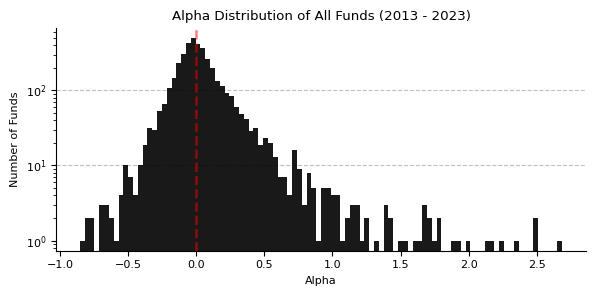

Alpha Distribution of All Funds (2013 - 2023) - Descriptive Stats


,alpha
count,4022.00
mean,0.04
std,0.26
min,-0.85
25%,-0.08
50%,0.00
75%,0.11
max,2.68


In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))


x = data_to_plot["alpha"]

ax.hist(x, bins=100, color="black", alpha=0.9)

ax.set_yscale("log")

ax.set_xlabel("Alpha")
ax.set_ylabel("Number of Funds")

ax.axhline(y=100, color="grey", alpha=0.5, linestyle="--", linewidth=0.8, zorder=-100)
ax.axhline(y=10, color="grey", alpha=0.5, linestyle="--", linewidth=0.8, zorder=-100)
ax.axvline(x=0, color="red", alpha=0.5, linestyle="--", linewidth=1.8, zorder=100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title("Alpha Distribution of All Funds (2013 - 2023)")

plt.tight_layout()
plt.show()

print("Alpha Distribution of All Funds (2013 - 2023) - Descriptive Stats")
pd.DataFrame(data_to_plot["alpha"].describe().round(2))

Our analysis focuses on a subset of 4,022 funds from the original pool of 13,000, spanning the years 2013 to 2023. This subset was selected based on criteria including a minimum of five reported quarters, possession of over five holdings, and a calculable three-year asset growth or decline rate.

Our findings reveal that 50% of the funds active within this timeframe have an Alpha of 0.0. This suggests a balanced distribution where half of the funds did not outperform the S&P 500, while the other half managed to surpass it. Remarkably, 25% of these funds achieved market outperformance by more than 11 percentage points, registering an Alpha of 0.11 or higher. Conversely, the bottom 25% of funds underperformed the market by at least 8%, indicated by an Alpha of -0.08 or lower.

## Conclusion

In 2023, the asset management industry witnessed a historical peak in activity, with over 7,000 funds filing a 13F, marking the highest number since records began in 1998. This growth trajectory, however, was not linear, with significant fluctuations influenced by macroeconomic events such as the dot-com bubble, the Global Financial Crisis (GFC), and the COVID-19 pandemic. These periods saw an initial surge in new fund entries, followed by a notable increase in exits, reflecting the industry's sensitivity to economic cycles.

An analysis of fund longevity and survival rates revealed that only 29% of the 2,256 funds active from 1998 to 2000 remained in operation by 2023. On average, funds maintained activity for around 7.22 years, though the standard deviation of 6.53 years indicates a broad dispersion in operational durations. Specifically, 25% of funds ceased operations within two years, while the median lifespan was five years. Notably, a quarter of all funds achieved a lifespan exceeding ten years.

The aggregate asset growth rates remained relatively flat from 2013 to early 2020, followed by a dramatic increase from early 2020 to the end of 2021. This period, marked by the COVID-19 pandemic and subsequent economic stimulus measures, saw holding values double from \$30 trillion to over \$60 trillion, only to decline as part of the 2022 market correction.

By calculating various performance metrics such as the Sharpe and Sortino ratios, along with alpha and beta, and analyzing the distribution of alpha, we discerned a division in fund performance over the last decade. Half of the funds underperformed the market, while the remaining half outperformed. Specifically, the bottom 25% of funds underperformed the market by more than 8%, whereas the top 25% exceeded market performance by more than 11% on a risk-adjusted basis.